<a href="https://colab.research.google.com/github/yosungcho/yosungcho.github.io/blob/main/12152025HRRunModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cpu
1. YOUR HR DATASET
  ✓ Normal: 356
  ✓ Hypertensive: 356

2. ODIR DATASET
  ✓ Hypertensive: 206
  ✓ Pure Normal: 2280

3. CATARACT DATASET (using labels)
  ✓ Normal fundus (cataract=0): 973 → labeled as non-HR
  ✓ Cataract disease (cataract=1): 939 → labeled as non-HR

4. GLAUCOMA DATASET (using labels)
  ✓ Normal fundus (glaucoma=0): 973 → labeled as non-HR
  ✓ Glaucoma disease (glaucoma=1): 906 → labeled as non-HR

5. DIABETIC DATASET (using labels)
  ✓ Normal fundus (DR=0): 973 → labeled as non-HR
  ✓ DR disease (DR=1): 998 → labeled as non-HR

COMBINED DATASET SUMMARY

┌────────────────────────────────┬─────────┬───────────┐
│ Source                         │ Count   │ HR Label  │
├────────────────────────────────┼─────────┼───────────┤
│ Your HR - Normal               │     356 │     0     │
│ Your HR - Hypertensive         │     356 │ 

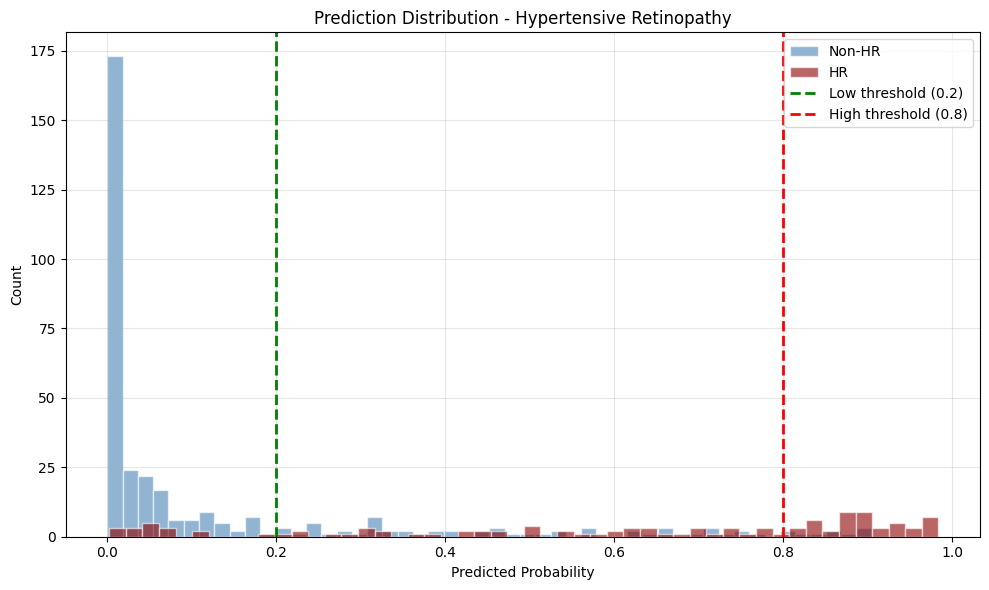


FALSE POSITIVE TEST BY SOURCE

CATARACT_NORMAL (41 images):
  Mean score: 0.0632
  Normal (≤0.2):    36 (87.8%)
  Uncertain:         5 (12.2%)
  HR (≥0.8):         0 (0.0%) ✓ Good!

CATARACT_DISEASE (30 images):
  Mean score: 0.0117
  Normal (≤0.2):    30 (100.0%)
  Uncertain:         0 (0.0%)
  HR (≥0.8):         0 (0.0%) ✓ Good!

GLAUCOMA_NORMAL (35 images):
  Mean score: 0.0662
  Normal (≤0.2):    31 (88.6%)
  Uncertain:         4 (11.4%)
  HR (≥0.8):         0 (0.0%) ✓ Good!

GLAUCOMA_DISEASE (35 images):
  Mean score: 0.0305
  Normal (≤0.2):    34 (97.1%)
  Uncertain:         1 (2.9%)
  HR (≥0.8):         0 (0.0%) ✓ Good!

DIABETIC_NORMAL (36 images):
  Mean score: 0.0917
  Normal (≤0.2):    31 (86.1%)
  Uncertain:         5 (13.9%)
  HR (≥0.8):         0 (0.0%) ✓ Good!

DIABETIC_DISEASE (42 images):
  Mean score: 0.0644
  Normal (≤0.2):    38 (90.5%)
  Uncertain:         3 (7.1%)
  HR (≥0.8):         1 (2.4%) ✓ Good!

ODIR_NORMAL (98 images):
  Mean score: 0.1927
  Normal (≤0.2)

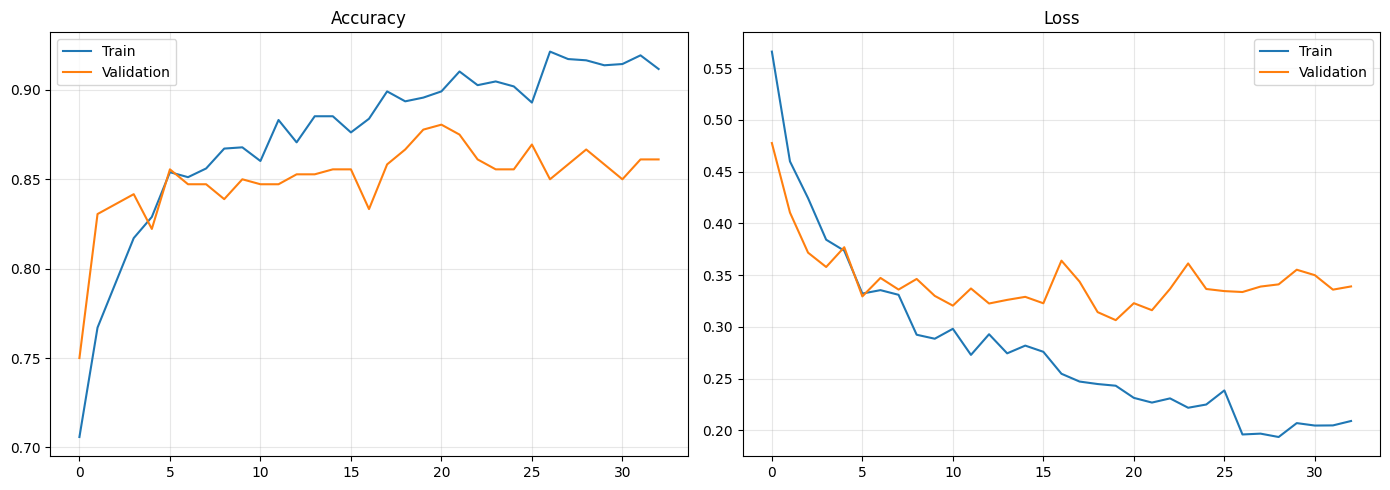

<Figure size 600x600 with 0 Axes>

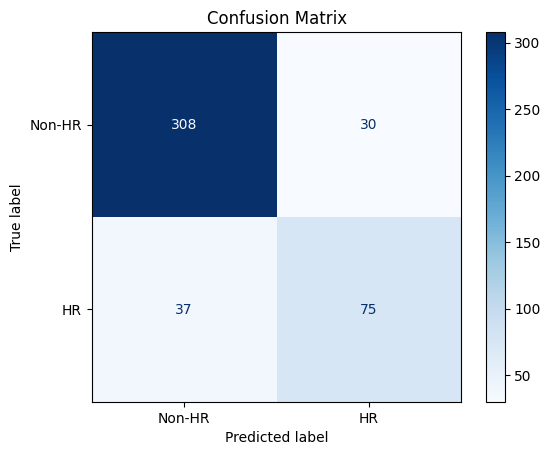

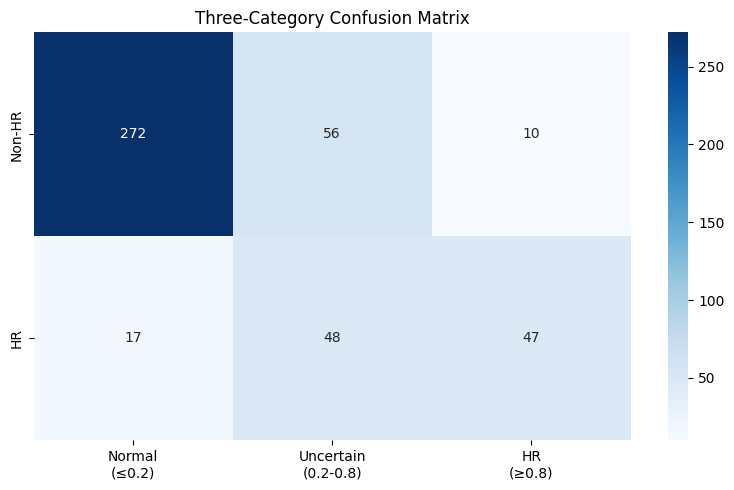


SAVING MODEL
✓ PyTorch: /content/drive/MyDrive/Jojo CNN/CNN Project 8-5/normal/HypertensiveResNet18_v4.pth


/tmp/ipython-input-359/2076783252.py:692: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(model_cpu, dummy, SAVE_PATH_ONNX, opset_version=11,


✓ ONNX: /content/drive/MyDrive/Jojo CNN/CNN Project 8-5/normal/HypertensiveResNet18_v4.onnx
Verify: PT=0.8652 ONNX=0.8652 ✓

FINAL SUMMARY - HR MODEL v4

✓ FIXED: Now uses label files to include NORMAL images from all datasets!

Training Data (using labels):
├─ Cataract Normal (binaryLabels=0): 973 → non-HR
├─ Cataract Disease (binaryLabels=1): 939 → non-HR
├─ Glaucoma Normal (binaryLabels=0): 973 → non-HR
├─ Glaucoma Disease (binaryLabels=1): 906 → non-HR
├─ Diabetic Normal (binaryLabels=0): 973 → non-HR
├─ Diabetic Disease (binaryLabels=1): 998 → non-HR
├─ ODIR Pure Normal: 2280 → non-HR
└─ Your HR + ODIR HR: 562 → HR

Test Results:
├─ Accuracy: 85.11%
├─ F1 Score: 0.6912
└─ ROC AUC:  0.8989

Upload to GCS:
!gsutil cp "/content/drive/MyDrive/Jojo CNN/CNN Project 8-5/normal/HypertensiveResNet18_v4.onnx" gs://jojo_project/HypertensiveResNet18_v4.onnx



In [ ]:
# === HYPERTENSIVE RETINOPATHY TRAINING v4 ===
# FIXED: Uses label files for Cataract Diabetic Glaucoma as non-HR images
# All normal images from all datasets are included as non-HR

!pip install --quiet torch torchvision scikit-learn matplotlib pillow seaborn onnx onnxruntime openpyxl

from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import copy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# === PATHS ===
BASE_PATH = '/content/drive/MyDrive/Jojo CNN'

# Your HR dataset
YOUR_HR_IMAGES = f'{BASE_PATH}/HyperTraining/TrainingImages'
YOUR_HR_LABELS_FOLDER = f'{BASE_PATH}/HyperTraining'

# ODIR dataset
ODIR_LABELS = f'{BASE_PATH}/KaggleA/ODIR-5K/ODIR-5K/data.xlsx'
ODIR_TRAIN_IMAGES = f'{BASE_PATH}/KaggleA/ODIR-5K/ODIR-5K/Training Images'

# Other disease datasets - WITH LABELS
CATARACT_IMAGES = f'{BASE_PATH}/cataract/Images C'
CATARACT_LABELS = f'{BASE_PATH}/cataract/CSV/Cataract Labels.csv'

GLAUCOMA_IMAGES = f'{BASE_PATH}/Glaucoma/Images'
GLAUCOMA_LABELS = f'{BASE_PATH}/Glaucoma/Excel/Labels.csv'

DIABETIC_IMAGES = f'{BASE_PATH}/Diabetic/Images'
DIABETIC_LABELS = f'{BASE_PATH}/Diabetic/CSV/Labels.csv'

# Output paths
SAVE_DIR = f'{BASE_PATH}/CNN Project 8-5/normal'
SAVE_PATH_PTH = f'{SAVE_DIR}/HypertensiveResNet18_v4.pth'
SAVE_PATH_ONNX = f'{SAVE_DIR}/HypertensiveResNet18_v4.onnx'

os.makedirs(SAVE_DIR, exist_ok=True)

# === CONFIGURATION ===
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 40
PATIENCE = 12
LEARNING_RATE = 3e-5

# ============================================================
# COLLECT ALL DATA
# ============================================================
all_images = []
all_labels = []
all_sources = []

# ============================================================
# 1. YOUR HR DATASET (Normal + Hypertensive)
# ============================================================
print("=" * 70)
print("1. YOUR HR DATASET")
print("=" * 70)

your_labels_file = None
for f in os.listdir(YOUR_HR_LABELS_FOLDER):
    if f.endswith('.csv'):
        your_labels_file = os.path.join(YOUR_HR_LABELS_FOLDER, f)
        break

your_df = pd.read_csv(your_labels_file)
image_col = 'Image' if 'Image' in your_df.columns else your_df.columns[0]
label_col = 'Hypertensive' if 'Hypertensive' in your_df.columns else your_df.columns[1]

your_label_map = {}
for _, r in your_df.iterrows():
    img_name = str(r[image_col]).strip()
    label = int(r[label_col])
    your_label_map[img_name.lower()] = label
    your_label_map[img_name] = label
    your_label_map[os.path.splitext(img_name)[0].lower()] = label

your_normal = 0
your_hr = 0
for fname in os.listdir(YOUR_HR_IMAGES):
    if not fname.lower().endswith(('.png', '.jpg', '.jpeg')):
        continue
    for key in [fname.lower(), fname, os.path.splitext(fname)[0].lower()]:
        if key in your_label_map:
            all_images.append(os.path.join(YOUR_HR_IMAGES, fname))
            all_labels.append(your_label_map[key])
            all_sources.append('your_hr_normal' if your_label_map[key] == 0 else 'your_hr_disease')
            if your_label_map[key] == 0:
                your_normal += 1
            else:
                your_hr += 1
            break

print(f"  ✓ Normal: {your_normal}")
print(f"  ✓ Hypertensive: {your_hr}")

# ============================================================
# 2. ODIR DATASET (HR + Pure Normal)
# ============================================================
print("\n" + "=" * 70)
print("2. ODIR DATASET")
print("=" * 70)

odir_hr_count = 0
odir_normal_count = 0

if os.path.exists(ODIR_LABELS):
    odir_df = pd.read_excel(ODIR_LABELS)

    # Hypertensive cases
    hr_positive = odir_df[odir_df['H'] == 1]
    for _, row in hr_positive.iterrows():
        for img_col in ['Left-Fundus', 'Right-Fundus']:
            img_path = os.path.join(ODIR_TRAIN_IMAGES, str(row[img_col]))
            if os.path.exists(img_path):
                all_images.append(img_path)
                all_labels.append(1)
                all_sources.append('odir_hr')
                odir_hr_count += 1

    # Pure normal cases
    pure_normal = odir_df[(odir_df['N'] == 1) &
                          (odir_df['D'] == 0) & (odir_df['G'] == 0) &
                          (odir_df['C'] == 0) & (odir_df['A'] == 0) &
                          (odir_df['H'] == 0) & (odir_df['M'] == 0) & (odir_df['O'] == 0)]

    for _, row in pure_normal.iterrows():
        for img_col in ['Left-Fundus', 'Right-Fundus']:
            img_path = os.path.join(ODIR_TRAIN_IMAGES, str(row[img_col]))
            if os.path.exists(img_path):
                all_images.append(img_path)
                all_labels.append(0)
                all_sources.append('odir_normal')
                odir_normal_count += 1

    print(f"  ✓ Hypertensive: {odir_hr_count}")
    print(f"  ✓ Pure Normal: {odir_normal_count}")

# ============================================================
# 3. CATARACT DATASET (Using Labels - Normal + Disease)
# ============================================================
print("\n" + "=" * 70)
print("3. CATARACT DATASET (using labels)")
print("=" * 70)

cataract_normal = 0
cataract_disease = 0

if os.path.exists(CATARACT_IMAGES) and os.path.exists(CATARACT_LABELS):
    cataract_df = pd.read_csv(CATARACT_LABELS)

    # Drop rows with NaN values
    cataract_df = cataract_df.dropna(subset=['imageID', 'binaryLabels'])

    # Create label map
    cataract_label_map = {}
    for _, r in cataract_df.iterrows():
        img_id = str(r['imageID']).strip()
        label = int(r['binaryLabels'])
        cataract_label_map[img_id.lower()] = label
        cataract_label_map[img_id] = label

    for fname in os.listdir(CATARACT_IMAGES):
        if not fname.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue

        # Try to match filename to label
        matched = False
        for key in [fname.lower(), fname, os.path.splitext(fname)[0].lower(), os.path.splitext(fname)[0]]:
            if key in cataract_label_map:
                orig_label = cataract_label_map[key]
                all_images.append(os.path.join(CATARACT_IMAGES, fname))
                all_labels.append(0)  # ALL cataract images are non-HR
                all_sources.append('cataract_normal' if orig_label == 0 else 'cataract_disease')
                if orig_label == 0:
                    cataract_normal += 1
                else:
                    cataract_disease += 1
                matched = True
                break

        if not matched:
            # Include anyway as disease (assume unlabeled = disease)
            all_images.append(os.path.join(CATARACT_IMAGES, fname))
            all_labels.append(0)
            all_sources.append('cataract_disease')
            cataract_disease += 1

    print(f"  ✓ Normal fundus (cataract=0): {cataract_normal} → labeled as non-HR")
    print(f"  ✓ Cataract disease (cataract=1): {cataract_disease} → labeled as non-HR")
else:
    print(f"  ⚠️ Cataract not found")

# ============================================================
# 4. GLAUCOMA DATASET (Using Labels - Normal + Disease)
# ============================================================
print("\n" + "=" * 70)
print("4. GLAUCOMA DATASET (using labels)")
print("=" * 70)

glaucoma_normal = 0
glaucoma_disease = 0

if os.path.exists(GLAUCOMA_IMAGES) and os.path.exists(GLAUCOMA_LABELS):
    glaucoma_df = pd.read_csv(GLAUCOMA_LABELS)

    glaucoma_label_map = {}
    for _, r in glaucoma_df.iterrows():
        img_id = str(r['imageID']).strip()
        label = int(r['binaryLabels'])
        glaucoma_label_map[img_id.lower()] = label
        glaucoma_label_map[img_id] = label

    for fname in os.listdir(GLAUCOMA_IMAGES):
        if not fname.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue

        matched = False
        for key in [fname.lower(), fname, os.path.splitext(fname)[0].lower(), os.path.splitext(fname)[0]]:
            if key in glaucoma_label_map:
                orig_label = glaucoma_label_map[key]
                all_images.append(os.path.join(GLAUCOMA_IMAGES, fname))
                all_labels.append(0)  # ALL glaucoma images are non-HR
                all_sources.append('glaucoma_normal' if orig_label == 0 else 'glaucoma_disease')
                if orig_label == 0:
                    glaucoma_normal += 1
                else:
                    glaucoma_disease += 1
                matched = True
                break

    print(f"  ✓ Normal fundus (glaucoma=0): {glaucoma_normal} → labeled as non-HR")
    print(f"  ✓ Glaucoma disease (glaucoma=1): {glaucoma_disease} → labeled as non-HR")
else:
    print(f"  ⚠️ Glaucoma not found")

# ============================================================
# 5. DIABETIC DATASET (Using Labels - Normal + Disease)
# ============================================================
print("\n" + "=" * 70)
print("5. DIABETIC DATASET (using labels)")
print("=" * 70)

diabetic_normal = 0
diabetic_disease = 0

if os.path.exists(DIABETIC_IMAGES) and os.path.exists(DIABETIC_LABELS):
    diabetic_df = pd.read_csv(DIABETIC_LABELS)

    # Drop rows with NaN values
    diabetic_df = diabetic_df.dropna(subset=['imageID', 'binaryLabels'])

    diabetic_label_map = {}
    for _, r in diabetic_df.iterrows():
        img_id = str(r['imageID']).strip()
        label = int(r['binaryLabels'])
        diabetic_label_map[img_id.lower()] = label
        diabetic_label_map[img_id] = label

    for fname in os.listdir(DIABETIC_IMAGES):
        if not fname.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue

        matched = False
        for key in [fname.lower(), fname, os.path.splitext(fname)[0].lower(), os.path.splitext(fname)[0]]:
            if key in diabetic_label_map:
                orig_label = diabetic_label_map[key]
                all_images.append(os.path.join(DIABETIC_IMAGES, fname))
                all_labels.append(0)  # ALL diabetic images are non-HR
                all_sources.append('diabetic_normal' if orig_label == 0 else 'diabetic_disease')
                if orig_label == 0:
                    diabetic_normal += 1
                else:
                    diabetic_disease += 1
                matched = True
                break

    print(f"  ✓ Normal fundus (DR=0): {diabetic_normal} → labeled as non-HR")
    print(f"  ✓ DR disease (DR=1): {diabetic_disease} → labeled as non-HR")
else:
    print(f"  ⚠️ Diabetic not found")

# ============================================================
# DATASET SUMMARY
# ============================================================
print("\n" + "=" * 70)
print("COMBINED DATASET SUMMARY")
print("=" * 70)

n_hr = all_labels.count(1)
n_non_hr = all_labels.count(0)

total_normal_fundus = your_normal + odir_normal_count + cataract_normal + glaucoma_normal + diabetic_normal
total_other_disease = cataract_disease + glaucoma_disease + diabetic_disease

print(f"""
┌────────────────────────────────┬─────────┬───────────┐
│ Source                         │ Count   │ HR Label  │
├────────────────────────────────┼─────────┼───────────┤
│ Your HR - Normal               │ {your_normal:7d} │     0     │
│ Your HR - Hypertensive         │ {your_hr:7d} │     1     │
│ ODIR - Hypertensive            │ {odir_hr_count:7d} │     1     │
│ ODIR - Pure Normal             │ {odir_normal_count:7d} │     0     │
├────────────────────────────────┼─────────┼───────────┤
│ Cataract - Normal fundus       │ {cataract_normal:7d} │     0     │
│ Cataract - Disease             │ {cataract_disease:7d} │     0     │
│ Glaucoma - Normal fundus       │ {glaucoma_normal:7d} │     0     │
│ Glaucoma - Disease             │ {glaucoma_disease:7d} │     0     │
│ Diabetic - Normal fundus       │ {diabetic_normal:7d} │     0     │
│ Diabetic - Disease             │ {diabetic_disease:7d} │     0     │
├────────────────────────────────┼─────────┼───────────┤
│ TOTAL                          │ {len(all_images):7d} │           │
│ Total Normal Fundus (non-HR)   │ {total_normal_fundus:7d} │     0     │
│ Total Other Diseases (non-HR)  │ {total_other_disease:7d} │     0     │
│ Total Hypertensive             │ {n_hr:7d} │     1     │
└────────────────────────────────┴─────────┴───────────┘
""")

# ============================================================
# BALANCE DATASET
# ============================================================
print("=" * 70)
print("BALANCING DATASET")
print("=" * 70)

max_non_hr = n_hr * 3

if n_non_hr > max_non_hr:
    print(f"Non-HR ({n_non_hr}) > 3x HR ({n_hr}). Sampling down to ~{max_non_hr}...")

    hr_data = [(img, lbl, src) for img, lbl, src in zip(all_images, all_labels, all_sources) if lbl == 1]
    non_hr_data = [(img, lbl, src) for img, lbl, src in zip(all_images, all_labels, all_sources) if lbl == 0]

    np.random.seed(42)
    indices = np.random.choice(len(non_hr_data), size=max_non_hr, replace=False)
    non_hr_sampled = [non_hr_data[i] for i in indices]

    all_data = hr_data + non_hr_sampled
    np.random.shuffle(all_data)

    all_images = [d[0] for d in all_data]
    all_labels = [d[1] for d in all_data]
    all_sources = [d[2] for d in all_data]

    # Count by source after sampling
    source_counts = {}
    for src in all_sources:
        source_counts[src] = source_counts.get(src, 0) + 1

    print(f"\n✓ After balancing: {len(all_images)} images")
    print(f"  Non-HR: {all_labels.count(0)}, HR: {all_labels.count(1)}")
    print(f"\n  By source:")
    for src, count in sorted(source_counts.items()):
        print(f"    {src}: {count}")
else:
    print("Dataset is reasonably balanced")

# ============================================================
# DATASET & TRANSFORMS
# ============================================================
class HRDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        try:
            image = Image.open(self.image_paths[idx]).convert('RGB')
        except:
            image = Image.new('RGB', (IMG_SIZE, IMG_SIZE), (0, 0, 0))
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(self.labels[idx], dtype=torch.float32)

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ============================================================
# TRAIN/VAL/TEST SPLIT
# ============================================================
print("\n" + "=" * 70)
print("SPLITTING DATA")
print("=" * 70)

X_trainval, X_test, y_trainval, y_test, src_trainval, src_test = train_test_split(
    all_images, all_labels, all_sources, test_size=0.2, random_state=42, stratify=all_labels
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=42, stratify=y_trainval
)

print(f"Training:   {len(X_train)}")
print(f"Validation: {len(X_val)}")
print(f"Test:       {len(X_test)}")

train_loader = DataLoader(HRDataset(X_train, y_train, train_transform), batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(HRDataset(X_val, y_val, val_transform), batch_size=BATCH_SIZE, num_workers=2)
test_loader = DataLoader(HRDataset(X_test, y_test, val_transform), batch_size=BATCH_SIZE, num_workers=2)

# ============================================================
# BUILD MODEL
# ============================================================
print("\n" + "=" * 70)
print("BUILDING MODEL")
print("=" * 70)

model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

for name, param in model.named_parameters():
    if 'layer3' not in name and 'layer4' not in name and 'fc' not in name:
        param.requires_grad = False

model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, 1),
    nn.Sigmoid()
)
model = model.to(device)

print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# ============================================================
# TRAINING
# ============================================================
criterion = nn.BCELoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-3)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

def train_model(model, train_loader, val_loader, num_epochs, patience):
    best_val_acc = 0
    best_model_wts = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(num_epochs):
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device).unsqueeze(1)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * images.size(0)
            train_correct += ((outputs > 0.5).float() == labels).sum().item()
            train_total += labels.size(0)

        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device).unsqueeze(1)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                val_correct += ((outputs > 0.5).float() == labels).sum().item()
                val_total += labels.size(0)

        train_loss /= train_total
        val_loss /= val_total
        train_acc = train_correct / train_total
        val_acc = val_correct / val_total

        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1:2d}/{num_epochs} | Train: {train_loss:.4f} ({train_acc:.4f}) | "
              f"Val: {val_loss:.4f} ({val_acc:.4f})", end="")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
            print(" ✓")
        else:
            epochs_no_improve += 1
            print()
            if epochs_no_improve >= patience:
                print(f"\nEarly stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_model_wts)
    return model, history, best_val_acc

print("\n" + "=" * 70)
print("TRAINING")
print("=" * 70)

model, history, best_val_acc = train_model(model, train_loader, val_loader, EPOCHS, PATIENCE)
print(f"\nBest validation accuracy: {best_val_acc:.4f}")

# ============================================================
# EVALUATION
# ============================================================
print("\n" + "=" * 70)
print("TEST SET EVALUATION")
print("=" * 70)

model.eval()
all_probs, all_labels_test = [], []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        all_probs.extend(outputs.cpu().numpy().flatten())
        all_labels_test.extend(labels.numpy())

y_prob = np.array(all_probs)
y_test_np = np.array(all_labels_test)
y_pred_binary = (y_prob > 0.5).astype(int)

acc = np.mean(y_pred_binary == y_test_np)
f1 = f1_score(y_test_np, y_pred_binary)
auc = roc_auc_score(y_test_np, y_prob)

print(f"\n🎯 TEST RESULTS:")
print(f"  Accuracy: {acc*100:.2f}%")
print(f"  F1 Score: {f1:.4f}")
print(f"  ROC AUC:  {auc:.4f}")

# Prediction Distribution
plt.figure(figsize=(10, 6))
plt.hist(y_prob[y_test_np == 0], bins=50, alpha=0.6, label='Non-HR', color='steelblue', edgecolor='white')
plt.hist(y_prob[y_test_np == 1], bins=50, alpha=0.6, label='HR', color='darkred', edgecolor='white')
plt.axvline(x=0.2, color='green', linestyle='--', linewidth=2, label='Low threshold (0.2)')
plt.axvline(x=0.8, color='red', linestyle='--', linewidth=2, label='High threshold (0.8)')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.title('Prediction Distribution - Hypertensive Retinopathy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# FALSE POSITIVE TEST BY SOURCE (CRITICAL!)
# ============================================================
print("\n" + "=" * 70)
print("FALSE POSITIVE TEST BY SOURCE")
print("=" * 70)

source_types = [
    'cataract_normal', 'cataract_disease',
    'glaucoma_normal', 'glaucoma_disease',
    'diabetic_normal', 'diabetic_disease',
    'odir_normal'
]

for source_type in source_types:
    indices = [i for i in range(len(X_test)) if src_test[i] == source_type]
    if len(indices) > 0:
        probs = []
        for idx in indices:
            img = val_transform(Image.open(X_test[idx]).convert('RGB')).unsqueeze(0).to(device)
            with torch.no_grad():
                probs.append(model(img).item())
        probs = np.array(probs)

        fp_count = (probs >= 0.8).sum()
        status = "✓ Good!" if (probs >= 0.8).mean() < 0.05 else "⚠️ Too high!"

        print(f"\n{source_type.upper()} ({len(probs)} images):")
        print(f"  Mean score: {probs.mean():.4f}")
        print(f"  Normal (≤0.2):   {(probs <= 0.2).sum():3d} ({(probs <= 0.2).mean()*100:.1f}%)")
        print(f"  Uncertain:       {((probs > 0.2) & (probs < 0.8)).sum():3d} ({((probs > 0.2) & (probs < 0.8)).mean()*100:.1f}%)")
        print(f"  HR (≥0.8):       {fp_count:3d} ({(probs >= 0.8).mean()*100:.1f}%) {status}")

# ============================================================
# VISUALIZATIONS
# ============================================================
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train')
plt.plot(history['val_acc'], label='Validation')
plt.title('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train')
plt.plot(history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Confusion matrix
cm = confusion_matrix(y_test_np, y_pred_binary)
disp = ConfusionMatrixDisplay(cm, display_labels=['Non-HR', 'HR'])
plt.figure(figsize=(6, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()

# Three-category
def classify_three(prob):
    if prob <= 0.2: return 0
    elif prob >= 0.8: return 2
    else: return 1

y_pred_three = np.array([classify_three(p) for p in y_prob])
cm_three = np.zeros((2, 3), dtype=int)
for actual, pred in zip(y_test_np, y_pred_three):
    cm_three[int(actual), pred] += 1

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(cm_three, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal\n(≤0.2)', 'Uncertain\n(0.2-0.8)', 'HR\n(≥0.8)'],
            yticklabels=['Non-HR', 'HR'], ax=ax)
ax.set_title('Three-Category Confusion Matrix')
plt.tight_layout()
plt.show()

# ============================================================
# SAVE MODEL
# ============================================================
print("\n" + "=" * 70)
print("SAVING MODEL")
print("=" * 70)

torch.save({
    'model_state_dict': model.state_dict(),
    'accuracy': acc,
    'f1_score': f1,
    'roc_auc': auc,
}, SAVE_PATH_PTH)
print(f"✓ PyTorch: {SAVE_PATH_PTH}")

# ONNX
import onnx
import onnxruntime as ort

model_cpu = model.cpu()
model_cpu.eval()

for f in [SAVE_PATH_ONNX, SAVE_PATH_ONNX + '.data']:
    if os.path.exists(f):
        os.remove(f)

dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)
torch.onnx.export(model_cpu, dummy, SAVE_PATH_ONNX, opset_version=11,
                  input_names=['input'], output_names=['output'], dynamo=False)

if os.path.exists(SAVE_PATH_ONNX + '.data'):
    model_onnx = onnx.load(SAVE_PATH_ONNX)
    onnx.save(model_onnx, SAVE_PATH_ONNX)
    os.remove(SAVE_PATH_ONNX + '.data')

print(f"✓ ONNX: {SAVE_PATH_ONNX}")

# Verify
session = ort.InferenceSession(SAVE_PATH_ONNX)
test_img = val_transform(Image.open(X_test[0]).convert('RGB')).unsqueeze(0)
with torch.no_grad():
    pt_out = model_cpu(test_img).item()
onnx_out = session.run(['output'], {'input': test_img.numpy()})[0][0][0]
print(f"Verify: PT={pt_out:.4f} ONNX={onnx_out:.4f} {'✓' if abs(pt_out-onnx_out)<0.01 else '❌'}")

# ============================================================
# FINAL SUMMARY
# ============================================================
print("\n" + "=" * 70)
print("FINAL SUMMARY - HR MODEL v4")
print("=" * 70)
print(f"""
✓ FIXED: Now uses label files to include NORMAL images from all datasets!

Training Data (using labels):
├─ Cataract Normal (binaryLabels=0): {cataract_normal} → non-HR
├─ Cataract Disease (binaryLabels=1): {cataract_disease} → non-HR
├─ Glaucoma Normal (binaryLabels=0): {glaucoma_normal} → non-HR
├─ Glaucoma Disease (binaryLabels=1): {glaucoma_disease} → non-HR
├─ Diabetic Normal (binaryLabels=0): {diabetic_normal} → non-HR
├─ Diabetic Disease (binaryLabels=1): {diabetic_disease} → non-HR
├─ ODIR Pure Normal: {odir_normal_count} → non-HR
└─ Your HR + ODIR HR: {your_hr + odir_hr_count} → HR

Test Results:
├─ Accuracy: {acc*100:.2f}%
├─ F1 Score: {f1:.4f}
└─ ROC AUC:  {auc:.4f}

Upload to GCS:
!gsutil cp "{SAVE_PATH_ONNX}" gs://jojo_project/HypertensiveResNet18_v4.onnx
""")
print("=" * 70)

